# Limpieza y estandarización de datos
## Índice
* [Librerías necesarias](#Librerías-necesarias)
* [Inspección inicial de los datos](#Inspección-inicial-de-los-datos)
    * [Metodo `info()`](#Metodo-`info()`)
    * [Metodo `describe()`](#Metodo-`describe()`)
    * [Método `value_counts()`](#Método-`value_counts()`)
* [Bases sobre estadística descriptiva](#Bases-sobre-estadística-descriptiva)
    * [Media y mediana](#Media-y-mediana)
    * [Desviación típica](#Desviación-típica)
    * [Percentiles](#Percentiles)
    * [Moda](#Moda)
* [Valores faltantes](#Valores-faltantes)
    * [Detección de valores faltantes](#Detección-de-valores-faltantes)
    * [Manejo de valores faltantes](#Manejo-de-valores-faltantes)
* [Manejo de duplicados](#Manejo-de-duplicados)
    * [Método `duplicated()`](#Método-`duplicated()`)
    * [Método `drop_duplicates()`](#Método-`drop_duplicates()`)
    * [Método `unique()`](#Método-`unique()`)
    * [Método `nunique()`](#Método-`nunique()`)
* [Detección y tratamiento de *outliers*](#Detección-y-tratamiento-de-*outliers*)
    * [¿Qué son los *outliers*?](#¿Qué-son-los-*outliers*?)
    * [Por qué son importantes los *outliers*?](#Por-qué-son-importantes-los-*outliers*?)
    * [Tipos de outliers](#Tipos-de-outliers)
    * [Métodos de detección](#Métodos-de-detección)
        * [Método del rango intercuartílico (IQR)](#Método-del-rango-intercuartílico-(IQR))
        * [Método de la desviación estándar o puntuación z (*z score*)](#Método-de-la-desviación-estándar-o-puntuación-z-(*z-score*))
* [Escala, normalización y estandarización de datos](#Escala,-normalización-y-estandarización-de-datos)
    * [Escalado mediante Z-score](#Escalado-mediante-Z-score)
    * [Normalización basada en el rango (Min-Max Scaling)](#Normalización-basada-en-el-rango-(Min-Max-Scaling))
    * [Normalización basada en la mediana y el rango intercuartílico (Robust Scaling)](#Normalización-basada-en-la-mediana-y-el-rango-intercuartílico-(Robust-Scaling))
* [Codificación de variables categóricas](#Codificación-de-variables-categóricas)
    * [*One-Hot Encoding*](#One-Hot-Encoding)
    * [*Label Encoding*](#Label-Encoding)
    * [*Ordinal Encoding*](#Ordinal-Encoding)
* [*Feature Transformation*, transformación de características](#Feature-Transformation,-transformación-de-características)
    * [Discretización](#Discretización)
* [División de características (*Feature Splitting*)](#División-de-características-(*Feature-Splitting*))
    * [División de fechas](#División-de-fechas)
    * [División de textos](#División-de-textos)


 ## Librerías necesarias
Para la limpieza y estandarización de datos, se utilizan principalmente las librerías `pandas` y `numpy`. La librería `pandas` proporciona herramientas para manipular y analizar datos en forma de DataFrames, mientras que `numpy` ofrece funciones para trabajar con arrays y realizar operaciones matemáticas. Estas librerías son fundamentales para realizar tareas como la detección de valores faltantes, el manejo de duplicados, la detección de *outliers* y la normalización de datos, entre otras tareas de limpieza y estandarización de datos.

También se pueden utilizar, para algunos cálculos, librerías más avanzadas como `scipy` que aporta cálculos matemáticos y estadísticos avanzados o `sklearn` para técnicas de preprocesamiento de datos, como la normalización y estandarización. Sin embargo, para las tareas básicas de limpieza y estandarización de datos, `pandas` y `numpy` son suficientes y ampliamente utilizadas en la comunidad de análisis de datos.

Si deseamos instalar estas librerías dentro de nuestro entorno de Conda podemos usar el siguiente comando en la terminal:
```bash
conda install pandas numpy scipy scikit-learn
```

No obstante, este cuaderno utiliza mayoritariamente la librería pandas para hacer todos los cálculos.

In [5]:
import pandas as pd
import numpy as np

## Inspección inicial de los datos
La librería pandas proporciona métodos para inspeccionar los datos, como `head()`, `info()`, `describe()`, y `value_counts()`. Estos métodos permiten obtener una visión general de los datos, identificar valores faltantes, determinar tipos de datos y distribuciones y detección de valores atípicos.
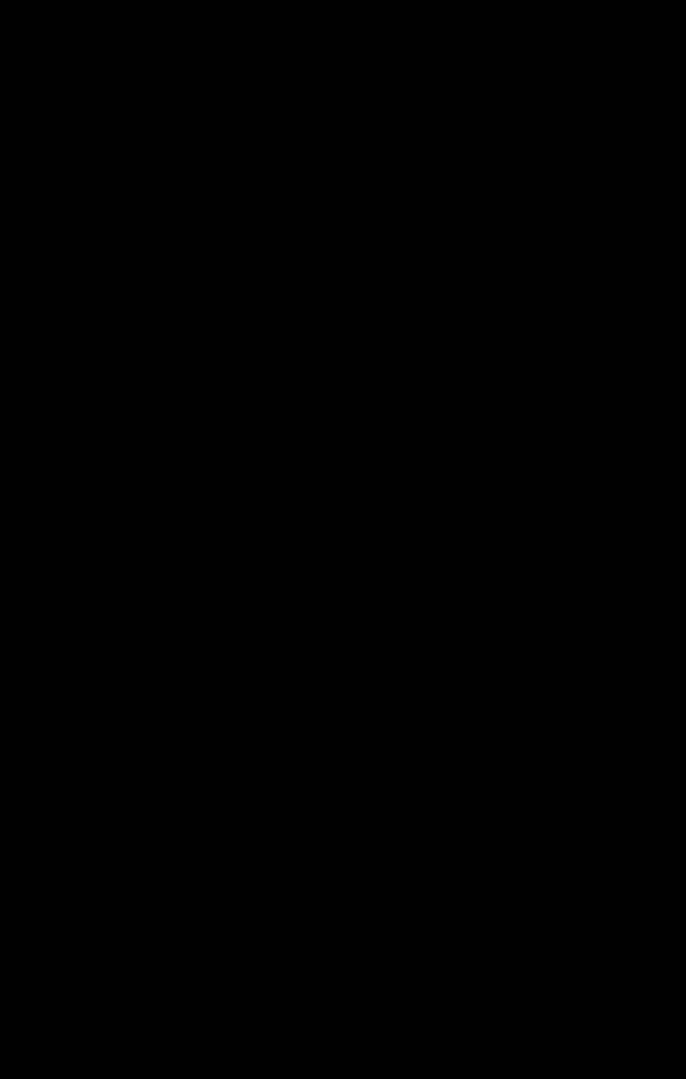

In [6]:
# DataFrame con valores diversos para inspección
dfEjemplo = pd.DataFrame({
    'cod_alumno': [1, 2, None, 4],
    'grupo': ['a', None, 'c', 'd'],
    'altura': [1.78, 1.89, 1.93, None]
})
dfEjemplo

,cod_alumno,grupo,altura
0,1.0,a,1.78
1,2.0,None,1.89
2,NaN,c,1.93
3,4.0,d,NaN


### Metodo `info()`
El método `info()` proporciona un resumen de la estructura del DataFrame, incluyendo el número de entradas, el número de valores no nulos y el tipo de datos de cada columna. Esto es útil para identificar columnas con valores faltantes y para entender la composición de los datos.

In [38]:
dfEjemplo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   cod_alumno  3 non-null      float64
 1   grupo       3 non-null      object 
 2   altura      3 non-null      float64
dtypes: float64(2), object(1)
memory usage: 228.0+ bytes


### Metodo `describe()`
El método `describe()` ofrece estadísticas descriptivas para las columnas numéricas, como la media, la desviación estándar, los valores mínimos y máximos, y los percentiles. Esto ayuda a identificar posibles valores atípicos y a comprender la distribución de los datos.

In [39]:
dfEjemplo.describe()

,cod_alumno,altura
count,3.000000,3.000000
mean,2.333333,1.866667
std,1.527525,0.077675
min,1.000000,1.780000
25%,1.500000,1.835000
50%,2.000000,1.890000
75%,3.000000,1.910000
max,4.000000,1.930000


En el ejemplo anterior, la columna `B` contiene valores de tipo objeto (cadenas de texto), por lo que `describe()` no proporciona estadísticas numéricas para esa columna.

Usando el parámetro `include='all'` en el método `describe()`, se pueden obtener estadísticas descriptivas para todas las columnas, incluyendo las de tipo objeto. Esto proporciona información sobre la cantidad de valores únicos, el valor más frecuente (top) y su frecuencia (freq) para las columnas de tipo objeto.


In [40]:
dfEjemplo.describe(include='all')


,cod_alumno,grupo,altura
count,3.000000,3,3.000000
unique,NaN,3,NaN
top,NaN,a,NaN
freq,NaN,1,NaN
mean,2.333333,NaN,1.866667
std,1.527525,NaN,0.077675
min,1.000000,NaN,1.780000
25%,1.500000,NaN,1.835000
50%,2.000000,NaN,1.890000
75%,3.000000,NaN,1.910000


El parámetro `percentiles` permite especificar los percentiles que se desean calcular. Por ejemplo, `percentiles=[0.25, 0.5, 0.75]` calculará el primer cuartil (25%), la mediana (50%) y el tercer cuartil (75%) para las columnas numéricas.
Pero podemos indicar otros rangos.

Ejemplo:

In [41]:
dfEjemplo.describe(percentiles=[0.33,0.66])

,cod_alumno,altura
count,3.000000,3.000000
mean,2.333333,1.866667
std,1.527525,0.077675
min,1.000000,1.780000
33%,1.660000,1.852600
50%,2.000000,1.890000
66%,2.640000,1.902800
max,4.000000,1.930000


Normalmente siempre aparece el percentil del 50% (mediana) en el resultado de `describe()`, incluso si no se especifica en el parámetro `percentiles`. Esto se debe a que la mediana es una medida de tendencia central importante y se incluye por defecto en las estadísticas descriptivas proporcionadas por `describe()`.

### Método `value_counts()`
El método `value_counts()` se utiliza para contar la frecuencia de cada valor único en una columna. Esto es especialmente útil para columnas de tipo objeto (cadenas de texto) o categóricas, ya que permite identificar la distribución de los valores en esa columna. En el ejemplo anterior, se puede usar `value_counts()` para obtener la frecuencia de cada valor en la columna `B`.

In [42]:
dfEjemplo['grupo'].value_counts()

grupo
a    1
c    1
d    1
Name: count, dtype: int64

`value`_counts()` dispone de un parámetro llamado `dropna` que, si se establece en `False`, incluirá los valores faltantes en el conteo. Esto es útil para obtener una visión completa de la distribución de los datos, incluyendo la cantidad de valores faltantes.

In [43]:
dfEjemplo['grupo'].value_counts(dropna=False)

grupo
a       1
None    1
c       1
d       1
Name: count, dtype: int64

## Bases sobre estadística descriptiva
La estadística descriptiva es una rama de la estadística que se encarga de resumir y describir las características principales de un conjunto de datos. Esto se logra a través de medidas de tendencia central, como la media, la mediana y la moda, y medidas de dispersión, como la desviación estándar, el rango y el rango intercuartílico. Estas medidas permiten obtener una visión general de los datos, identificar patrones y detectar posibles valores atípicos. La estadística descriptiva es fundamental para el análisis de datos, ya que proporciona información clave sobre la distribución y la variabilidad de los datos, lo que es esencial para tomar decisiones informadas y realizar análisis más profundos.
### Media y mediana
La media es el promedio de un conjunto de datos, calculado sumando todos los valores y dividiendo por el número total de valores. La mediana es el valor que se encuentra en el medio de un conjunto de datos ordenados. La media es sensible a los valores atípicos, mientras que la mediana es más robusta y no se ve afectada por los valores extremos. Por lo tanto, la mediana puede ser una mejor medida de tendencia central cuando los datos contienen valores atípicos o están sesgados.

In [44]:
dfDatos = pd.DataFrame({
    'id_trabajador': [1, 2, 3, 4, 5],
    'salario': [1200, 1320, 1430, 1540, 25000] # El valor 25000 es un valor atípico que afecta la media
})
media_salario = dfDatos['salario'].mean()
mediana_salario = dfDatos['salario'].median()
print(f"Media del salario: {media_salario}")
print(f"Mediana del salario: {mediana_salario}") # Refleja mejor el salario típico de los trabajadores, ya que no se ve afectada por el valor atípico de 25000

Media del salario: 6098.0
Mediana del salario: 1430.0


### Desviación típica
La desviación típica, también conocida como desviación estándar, es una medida de dispersión que indica cuánto se desvían los valores de un conjunto de datos con respecto a su media. Se calcula de esta forma:
1. Se calcula la media del conjunto de datos.
2. Se resta la media a cada valor del conjunto de datos para obtener las desviaciones individuales.
3. Se elevan al cuadrado las desviaciones individuales para obtener las desviaciones al cuadrado.
4. Se calcula la media de las desviaciones al cuadrado para obtener la varianza.
5. Se toma la raíz cuadrada de la varianza para obtener la desviación típica.

La desviación típica es útil para entender la variabilidad de los datos. Una desviación típica alta indica que los valores se dispersan ampliamente alrededor de la media, mientras que una desviación típica baja indica que los valores están más agrupados cerca de la media. La desviación típica es especialmente útil para comparar la dispersión de diferentes conjuntos de datos o para identificar valores atípicos.

In [45]:
dfDatos = pd.DataFrame({
    "A": [2, 2, 2, 2, 2], # Desviación típica de 0, ya que todos los valores son iguales a la media
    "B": [1, 2, 3, 4, 5], # Desviación típica de aproximadamente 1.58, ya que los valores se dispersan alrededor de la media (3)
    "C": [1, 2, 3, 4, 40] # Desviación típica de aproximadamente 15.17, ya que el valor 40 es un valor atípico que se encuentra muy alejado de la media (10), lo que aumenta significativamente la dispersión de los datos
})
print("Desviación típica de la columna A:", dfDatos["A"].std())
print("Desviación típica de la columna B:", dfDatos["B"].std())
print("Desviación típica de la columna C:", dfDatos["C"].std())

Desviación típica de la columna A: 0.0
Desviación típica de la columna B: 1.5811388300841898
Desviación típica de la columna C: 16.80773631397161


### Percentiles
Los percentiles son medidas que dividen un conjunto de datos ordenados en 100 partes iguales. Así el percentil 25 (Q1, primer cuartil) es el valor que separa el 25% inferior de los datos del 75% superior, el percentil 50 (Q2 o mediana) es el valor que separa el 50% inferior de los datos del 50% superior, y el percentil 75 (Q3) es el valor que separa el 75% inferior de los datos del 25% superior. Los percentiles son útiles para entender la distribución de los datos y para identificar valores atípicos. Por ejemplo, un valor que se encuentra por debajo del percentil 25 o por encima del percentil 75 puede considerarse un valor atípico.

In [46]:
dfDatos = pd.DataFrame({
    'id_trabajador': [1, 2, 3, 4, 5, 6, 7, 8, 9 , 10],
    'salario': [1000, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000]
})
Q1 = dfDatos['salario'].quantile(0.25) # Percentil 25 (primer cuartil)
Q2 = dfDatos['salario'].quantile(0.50) # Percentil 50 (mediana)
Q3 = dfDatos['salario'].quantile(0.75) # Percentil 75 (tercer cuartil)
print(f"Percentil 25 (Q1): {Q1}")
print(f"Percentil 50 (Q2 o mediana): {Q2}")
print(f"Percentil 75 (Q3): {Q3}")


Percentil 25 (Q1): 1325.0
Percentil 50 (Q2 o mediana): 1550.0
Percentil 75 (Q3): 1775.0


### Moda
La moda es la medida de tendencia central que representa el valor o los valores que ocurren con mayor frecuencia en un conjunto de datos. Un conjunto de datos puede tener una moda única (unimodal), varias modas (multimodal) o no tener moda si todos los valores son únicos. La moda es especialmente útil para describir datos categóricos o discretos, ya que indica el valor más común en la distribución de los datos. En algunos casos, la moda puede ser más representativa que la media o la mediana, especialmente cuando los datos contienen valores atípicos o están sesgados.

In [47]:
dfDatos = pd.DataFrame({
    'id_trabajador': [1, 2, 3, 4, 5, 6, 7, 8, 9 , 10],
    'departamento': ['Ventas', 'Marketing', 'Ventas', 'Recursos Humanos', 'Marketing', 'Ventas', 'Recursos Humanos', 'Marketing', 'Ventas', 'Recursos Humanos']
})
moda_departamento = dfDatos['departamento'].mode()
print(f"Moda del dato departamento: {moda_departamento[0]}") # El departamento de Ventas es el más común, ya que aparece 4 veces en el conjunto de datos, mientras que los departamentos de Marketing y Recursos Humanos aparecen 3 veces cada uno.
moda_id_trabajador = dfDatos['id_trabajador'].mode()
print(f"Moda del dato id_trabajador:\n {moda_id_trabajador}") # No hay moda, ya que todos los valores de id_trabajador son únicos y no se repiten, por lo que no hay un valor que ocurra con mayor frecuencia en esa columna.

Moda del dato departamento: Ventas
Moda del dato id_trabajador:
 0     1
1     2
2     3
3     4
4     5
5     6
6     7
7     8
8     9
9    10
Name: id_trabajador, dtype: int64


## Valores faltantes
### Detección de valores faltantes
Para detectar valores faltantes, se pueden usar métodos como `isnull()` o `isna()`, que devuelven un DataFrame booleano indicando la presencia de valores faltantes.

In [48]:
dfValoresFaltas = pd.DataFrame({
    'A': [1, 2, None, 4],
    'B': ['a', None, 'c', 'd'],
    'C': [None, None, None, None]
})
print(dfValoresFaltas.isnull())

       A      B     C
0  False  False  True
1  False   True  True
2   True  False  True
3  False  False  True


También se puede usar `sum()` para contar el número de valores faltantes en cada columna.

In [49]:
print(dfValoresFaltas.isnull().sum())

A    1
B    1
C    4
dtype: int64


In [50]:
print(dfValoresFaltas.isna())

       A      B     C
0  False  False  True
1  False   True  True
2   True  False  True
3  False  False  True


Tanto `isnull()` como `isna()` se pueden usar indistintamente para detectar valores faltantes en un DataFrame. Ambos devuelven un DataFrame booleano donde `True` indica la presencia de un valor faltante (NaN) y `False` indica la ausencia de un valor faltante. Por lo tanto, no hay diferencia funcional entre ellos, y puedes usar cualquiera de los dos según tu preferencia.

### Manejo de valores faltantes
Pandas ofrece varias formas de manejar los valores faltantes, como `dropna()` para eliminar filas o columnas con valores faltantes, y `fillna()` para rellenar los valores faltantes con un valor específico.

El método `dropna()` se puede usar para eliminar filas o columnas que contienen valores faltantes. Por ejemplo, `df.dropna()` eliminará todas las filas que contengan al menos un valor faltante, mientras que `df.dropna(axis=1)` eliminará todas las columnas que contengan al menos un valor faltante.

In [51]:
dfAlgunasFaltas = pd.DataFrame({
    'A': [1, 2, 3, 4],
    'B': ['a', None, 'c', 'd'],
    'C': [10, None, None, 20]})
dfAlgunasFaltas.dropna() # Solo hay dos filas sin valores faltantes, por lo que solo se mantienen esas filas

,A,B,C
0,1,a,10.0
3,4,d,20.0


In [52]:
dfAlgunasFaltas.dropna(axis=1) # Solo hay una columna sin valores faltantes, por lo que solo se mantiene esa columna

,A
0,1
1,2
2,3
3,4



El método `fillna()` se puede usar para rellenar los valores faltantes con un valor específico. Por ejemplo, `df.fillna(0)` reemplazará todos los valores faltantes con 0.

In [53]:
dfCopia = dfValoresFaltas.copy() # Para no modificar el DataFrame original
dfCopia["A"]=dfCopia["A"].fillna(0) # Rellenar los valores faltantes en la columna A con 0
dfCopia

,A,B,C
0,1.0,a,None
1,2.0,None,None
2,0.0,c,None
3,4.0,d,None


## Manejo de duplicados
Los duplicados son filas que contienen los mismos valores en todas las columnas. La presencia de duplicados puede afectar el análisis de datos y los resultados de los modelos de machine learning, por lo que es importante detectarlos y tratarlos adecuadamente.
### Método `duplicated()`
El método `duplicated()` devuelve un DataFrame booleano indicando la presencia de filas duplicadas. Ese DataFrame nos puede servir como filtro para obtener solo las filas no duplicadas de un DataFrame

In [54]:
dfDuplicados = pd.DataFrame({
    'A': [1, 1, 2, 3],
    'B': ['a', 'a', 'b', 'c'],
    'C': [10, 10, 20, 30]
})
print(dfDuplicados.duplicated()) # En la segunda fila se detecta un duplicado, ya que es idéntica a la primera fila

0    False
1     True
2    False
3    False
dtype: bool


In [55]:
filtro = ~dfDuplicados.duplicated() # Filtro para obtener solo las filas no duplicadas
dfSinDuplicados = dfDuplicados[filtro] # Aplicar el filtro al DataFrame
print(dfSinDuplicados)

   A  B   C
0  1  a  10
2  2  b  20
3  3  c  30


Este método posee los siguientes parámetros:
* `keep`: Este parámetro determina qué filas duplicadas se consideran como duplicados. Puede tomar los siguientes valores:
  * `'first'`: Mantiene la primera aparición de cada fila duplicada y marca las siguientes como duplicados (valor predeterminado).
  * `'last'`: Mantiene la última aparición de cada fila duplicada y marca las anteriores como duplicados.
  * `False`: Marca todas las filas duplicadas como duplicados, sin mantener ninguna de ellas.
* `subset`: Este parámetro permite especificar un subconjunto de columnas para considerar al identificar duplicados. Si se proporciona una lista de columnas, solo se considerarán esas columnas para determinar si una fila es un duplicado. Si no se especifica, se considerarán todas las columnas del DataFrame para identificar duplicados.
* `inplace`: Este parámetro, si se establece en `True`, modificará el DataFrame original eliminando las filas duplicadas en lugar de devolver un nuevo DataFrame. Si se establece en `False` (valor predeterminado), se devolverá un nuevo DataFrame con las filas duplicadas eliminadas, y el DataFrame original permanecerá sin cambios.

### Método `drop_duplicates()`
El método `drop_duplicates()` se utiliza para eliminar las filas duplicadas de un DataFrame. Por defecto, `drop_duplicates()` mantiene la primera aparición de cada fila duplicada y elimina las siguientes.

In [56]:
dfDuplicados.drop_duplicates() # Se elimina la segunda fila, ya que es un duplicado de la primera fila

,A,B,C
0,1,a,10
2,2,b,20
3,3,c,30


### Método `unique()`
El método `unique()` se utiliza para obtener los valores únicos de una columna específica. Esto es útil para identificar los valores distintos presentes en una columna y para detectar posibles duplicados en esa columna. Los valores únicos se devuelven como un array de NumPy.


Este método también tiene los mismos parámetros que `duplicated()`, como `keep` y `subset`, que permiten controlar qué filas duplicadas se eliminan y qué columnas se consideran para identificar duplicados.

In [57]:
duplicados = dfDuplicados["A"].unique()
print(duplicados) # Devuelve los valores únicos de la columna A, que son 1, 2 y 3

[1 2 3]


### Método `nunique()`
El método `nunique()` se utiliza para contar el número de valores únicos en una columna específica. Esto es útil para obtener una visión general de la diversidad de valores presentes en una columna y para detectar posibles duplicados. El resultado es un número entero que representa la cantidad de valores únicos en la columna.

In [58]:
print("Valores diferentes en la columna A:",dfDuplicados["A"].nunique()) # Devuelve el número de valores únicos en la columna A, que es 3
print("Valores duplicados en la columna A:",dfDuplicados["A"].count()-dfDuplicados["A"].nunique()) # Devuelve el número de valores duplicados en la columna A, que es 1 (el valor 1 se repite dos veces)

Valores diferentes en la columna A: 3
Valores duplicados en la columna A: 1


## Detección y tratamiento de *outliers*
### ¿Qué son los *outliers*?
Los *outliers* son valores que se encuentran significativamente alejados de la mayoría de los datos. Por lo tanto no mantienen el patrón general de distribución de los datos.

Los outliers pueden deberse a:
* Errores de medición o entrada de datos
* Variabilidad natural en los datos
* Condiciones especiales o eventos raros
* Errores al registrar o procesar los datos

### Por qué son importantes los *outliers*?
Los *outliers* pueden tener un impacto significativo en el análisis de datos, ya que pueden distorsionar las estadísticas descriptivas, afectar la distribución de los datos y sesgar los resultados de los modelos de machine learning. Por lo tanto, es importante detectar y tratar los *outliers* adecuadamente para obtener resultados más precisos y confiables en el análisis de datos.

### Tipos de outliers
* **Por error de medición o entrada de datos**: Estos *outliers* pueden ser causados por errores humanos, fallos en los instrumentos de medición o problemas en el proceso de recolección de datos. Por ejemplo, un valor de temperatura registrado como 1000 grados Celsius en lugar de 10 grados Celsius sería un *outlier* causado por un error de medición.
* **Procedente de datos reales**: Estos *outliers* pueden ser causados por eventos raros o condiciones especiales que ocurren en el mundo real. Por ejemplo, un valor de ingresos extremadamente alto en un conjunto de datos de ingresos podría ser un *outlier* procedente de datos reales, ya que podría representar a una persona con ingresos excepcionalmente altos.

### Métodos de detección
Existen varios métodos para detectar *outliers*, como el método de los cuartiles, el método de la desviación estándar y el método de la puntuación z. Estos métodos se basan en diferentes enfoques para identificar valores que se encuentran significativamente alejados de la mayoría de los datos.
#### Método del rango intercuartílico (IQR)
El método del **rango intercuartílico** (**IQR**) es un enfoque común para detectar *outliers* en un conjunto de datos. El IQR se calcula como la diferencia entre el tercer cuartil (Q3) y el primer cuartil (Q1) de los datos. Los *outliers* se identifican como valores que se encuentran por debajo de Q1 - 1.5 * IQR o por encima de Q3 + 1.5 * IQR.

In [7]:
dfOutliers = pd.DataFrame({
    'A': [1, 2, 3, 4, 5, 100], # 100 es un outlier
    'B': [10, 20, 30, 40, 50, 60], # No hay outliers
    'C': [5, 6, 7, 8, 9, 10] # No hay outliers
})
Q1 = dfOutliers['A'].quantile(0.25) # Primer cuartil
Q3 = dfOutliers['A'].quantile(0.75) # Tercer cuartil
IQR = Q3 - Q1 # Rango intercuartílico
filtroOutliers = (dfOutliers['A'] < Q1 - 1.5 * IQR) | (dfOutliers['A'] > Q3 + 1.5 * IQR) # Filtro para identificar los outliers
outliers = dfOutliers[filtroOutliers] # Filtrar los outliers
print("Outliers de la columna 'A'\n",outliers['A']) # Imprimir los valores de la columna A que son outliers, en este caso el valor 100

Q1 = dfOutliers['B'].quantile(0.25) # Primer cuartil
Q3 = dfOutliers['B'].quantile(0.75) # Tercer cuartil
IQR = Q3 - Q1 # Rango intercuartílico
filtroOutliers = (dfOutliers['B'] < Q1 - 1.5 * IQR) | (dfOutliers['B'] > Q3 + 1.5 * IQR) # Filtro para identificar los outliers
outliers = dfOutliers[filtroOutliers] # Filtrar los outliers
print("\nOutliers de la columna 'B'\n",outliers['B']) # No hay outliers en la columna B, por lo que no se imprimirá ningún valor

Outliers de la columna 'A'
 5    100
Name: A, dtype: int64

Outliers de la columna 'B'
 Series([], Name: B, dtype: int64)


#### Método de la desviación estándar o puntuación z (*z score*)
El método de la **desviación estándar** o ***z score*** es otro enfoque para detectar *outliers* en un conjunto de datos. Se llama puntuación z (*z score*) a la cantidad de desviaciones estándar que un valor se encuentra por encima o por debajo de la media. Por ejemplo, un valor con una puntuación z de 3 se encuentra a 3 desviaciones estándar por encima de la media, mientras que un valor con una puntuación z de -2 se encuentra a 2 desviaciones estándar por debajo de la media.

Los *outliers* se identifican como valores que se encuentran a más de 3 desviaciones estándar de la media. Es decir, un valor se considera un *outlier* si es menor que la media menos 3 veces la desviación estándar o mayor que la media más 3 veces la desviación estándar.

In [60]:
dfOutliers = pd.DataFrame({
    'A': [1, 2, 3, 4, 5, 100], # 100 es un outlier
    'B': [10, 20, 30, 40, 50, 60], # No hay outliers
    'C': [5, 6, 7, 8, 9, 10] # No hay outliers
})
media_A = dfOutliers['A'].mean() # Media de la columna A
desviacion_A = dfOutliers['A'].std() # Desviación estándar de la columna A
filtroOutliers = (dfOutliers['A'] < media_A - 3 * desviacion_A) | (dfOutliers['A'] > media_A + 3 * desviacion_A) # Filtro para identificar los outliers
outliers = dfOutliers[filtroOutliers] # Filtrar los outliers
print("Outliers de la columna 'A'\n",outliers['A']) # Imprimir los valores de la columna A que son outliers, en este caso no se detecta el valor 100 como un outlier, ya que no se encuentra a más de 3 desviaciones estándar de la media

Outliers de la columna 'A'
 Series([], Name: A, dtype: int64)


In [14]:
dfOutliers = pd.DataFrame({
    'A': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 100], # 100 es un outlier
    'B': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130], # No hay outliers
    'C': [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17] # No hay outliers
})
media_A = dfOutliers['A'].mean() # Media de la columna A
print("Media de la columna A: ",media_A)
desviacion_A = dfOutliers['A'].std() # Desviación estándar de la columna A
print("Desviación de la columnas A:",desviacion_A)
filtroOutliers = (dfOutliers['A'] < media_A - 3 * desviacion_A) | (dfOutliers['A'] > media_A + 3 * desviacion_A) # Filtro para identificar los outliers
outliers = dfOutliers[filtroOutliers] # Filtrar los outliers
print("Outliers de la columna 'A'\n",outliers["A"]) # Imprimir los valores de la columna A que son outliers, en este caso se detecta el valor 100 como un outlier, ya que se encuentra a más de 3 desviaciones estándar de la media (media_A = 14.23 y desviacion_A = 27.39, por lo que 100 > media_A + 3 * desviacion_A)

Media de la columna A:  13.692307692307692
Desviación de la columnas A: 26.160990728514772
Outliers de la columna 'A'
 12    100
Name: A, dtype: int64


## Escala, normalización y estandarización de datos
En un DataFrame es muy habitual que haya columnas con diferentes escalas o unidades de medida. Por ejemplo, una columna puede contener valores de ingresos en dólares, mientras que otra columna puede contener valores de edad en años. Estas diferencias afectan especialmente a la aplicación en los datos de:
* **Algoritmos de machine learning** que se basan en la distancia entre los datos, como el k-vecinos más cercanos (KNN) o el clustering, ya que las diferencias en las escalas pueden hacer que un atributo domine sobre los demás.
* **Algoritmos de optimización**, como el descenso de gradiente, ya que las diferencias en las escalas pueden afectar la convergencia del algoritmo y hacer que sea más difícil encontrar el óptimo global.
* **Visualización de datos**, ya que las diferencias en las escalas pueden dificultar la interpretación de los gráficos y hacer que sea más difícil identificar patrones o tendencias en los datos.
* **Análisis estadístico**, ya que las diferencias en las escalas pueden afectar la interpretación de las estadísticas descriptivas y hacer que sea más difícil comparar los datos entre diferentes columnas.
* **Redes neuronales**, ya que las diferencias en las escalas pueden afectar la convergencia del modelo y hacer que sea más difícil encontrar los pesos óptimos durante el entrenamiento.

Por lo tanto, es importante escalar, normalizar o estandarizar los datos antes de aplicar algoritmos de machine learning, optimización, visualización o análisis estadístico para obtener resultados más precisos y confiables. Estas técnicas permiten que los datos estén en la misma escala y facilitan la comparación entre diferentes atributos, mejorando así el rendimiento de los modelos y la interpretación de los resultados.

### Escalado mediante Z-score
El escalado mediante Z-score, también conocido como estandarización, es una técnica de normalización que transforma los datos para que tengan una media de 0 y una desviación estándar de 1. Esto se logra utilizando la siguiente fórmula:
X_estandarizado = (X - media) / desviación estándar
Donde:
* X es el valor original del dato.
* media es la media de la columna.
* desviación estándar es la desviación estándar de la columna.
* X_estandarizado es el valor estandarizado del dato.

Mediante esta técnica se obtienen valores en el rango de aproximadamente -3 a 3, aunque pueden ser mayores o menores dependiendo de la presencia de valores atípicos en los datos. Por ejemplo, un valor con una puntuación z de 2 se encuentra a 2 desviaciones estándar por encima de la media, mientras que un valor con una puntuación z de -1 se encuentra a 1 desviación estándar por debajo de la media.

Esta técnica es útil cuando se desea comparar datos que tienen diferentes escalas o unidades de medida, ya que transforma los datos a una escala común. Sin embargo, es sensible a los valores atípicos, ya que estos pueden afectar significativamente la media y la desviación estándar, lo que a su vez afecta la estandarización de los datos.

In [46]:
df = pd.DataFrame({
    "nombre" : ["Juan", "María", "Pedro", "Ana", "Lucio"],
    "salario": [1200, 1900, 2500, 1300, 1600],
    "ventas" : [89000, 103000, 90000, 76000, 69000]
})
media_salario = df['salario'].mean() # Media de la columna salario
desviacion_salario = df['salario'].std() # Desviación estándar de la columna salario
media_ventas = df['ventas'].mean() # Media de la columna ventas
desviacion_ventas = df['ventas'].std() # Desviación estándar de la columna ventas
df['salario_estandarizado'] = (df['salario'] - media_salario) / desviacion_salario # Estandarizar la columna salario
df['ventas_estandarizadas'] = (df['ventas'] - media_ventas) / desviacion_ventas # Estandarizar la columna ventas
print(df)

  nombre  salario  ventas  salario_estandarizado  ventas_estandarizadas
0   Juan     1200   89000              -0.953463               0.271901
1  María     1900  103000               0.381385               1.329296
2  Pedro     2500   90000               1.525540               0.347430
3    Ana     1300   76000              -0.762770              -0.709965
4  Lucio     1600   69000              -0.190693              -1.238662


La librería `sklearn.preprocessing` ofrece una función llamada `StandardScaler` que implementa esta técnica de estandarización de manera eficiente y con menos código. Esta función calcula automáticamente la media y la desviación estándar de las columnas especificadas y devuelve un array de NumPy con los datos estandarizados, por lo que si queremos mantener el formato de DataFrame, debemos convertir ese array de nuevo a un DataFrame y asignarlo a una columna con el nombre que indiquemos.

In [47]:
from sklearn.preprocessing import StandardScaler
df = pd.DataFrame({
    "nombre" : ["Juan", "María", "Pedro", "Ana", "Lucio"],
    "salario": [1200, 1900, 2500, 1300, 1600],
    "ventas" : [89000, 103000, 90000, 76000, 69000]
})
scaler = StandardScaler() # Crear una instancia del escalador
array_estandarizado = scaler.fit_transform(df[['salario', 'ventas']]) # Estandarizar las columnas salario y ventas, el resultado es un array de NumPy
df_estandarizado = df.copy() # Crear una copia del DataFrame original para no modificarlo
df_estandarizado["salario_estandarizado"] = array_estandarizado[:, 0] # Asignar la primera columna del array estandarizado a la nueva columna salario_estandarizado
df_estandarizado["ventas_estandarizadas"] = array_estandarizado[:, 1] # Asignar la segunda columna del array estandarizado a la nueva columna ventas_estandarizadas
print(df_estandarizado)

  nombre  salario  ventas  salario_estandarizado  ventas_estandarizadas
0   Juan     1200   89000              -1.066004               0.303995
1  María     1900  103000               0.426401               1.486198
2  Pedro     2500   90000               1.705606               0.388438
3    Ana     1300   76000              -0.852803              -0.793765
4  Lucio     1600   69000              -0.213201              -1.384866



### Normalización basada en el rango (Min-Max Scaling)
La normalización basada en el rango, también conocida como *Min-Max Scaling*, es una técnica de normalización que transforma los datos para que estén en un rango específico, generalmente entre 0 y 1. Esto se logra utilizando la siguiente fórmula:
X_normalizado = (X - X_min) / (X_max - X_min)
Donde:
* X es el valor original del dato.
* X_min es el valor mínimo de la columna.
* X_max es el valor máximo de la columna.
Esta técnica es útil cuando se desea mantener la forma de la distribución de los datos, pero se quiere escalar los valores a un rango específico. Sin embargo, es sensible a los valores atípicos, ya que estos pueden afectar significativamente el valor mínimo y máximo, lo que a su vez afecta la normalización de los datos.

Ejemplo de normalización:

In [15]:
df = pd.DataFrame({
    "nombre" : ["Juan", "María", "Pedro", "Ana", "Lucio"],
    "salario": [1200, 1900, 2500, 1300, 1600],
    "ventas" : [89000, 103000, 90000, 76000, 69000]
})
df_normalizado = df.copy() # Crear una copia del DataFrame original para no modificarlo
salario_min = df['salario'].min() # Valor mínimo de la columna salario
salario_max = df['salario'].max() # Valor máximo de la columna salario
ventas_min = df['ventas'].min() # Valor mínimo de la columna ventas
ventas_max = df['ventas'].max() # Valor máximo de la columna ventas
df_normalizado['salario_normalizado'] = (df['salario'] - salario_min) / (salario_max - salario_min) # Normalizar la columna salario
df_normalizado['ventas_normalizadas'] = (df['ventas'] - ventas_min) / (ventas_max - ventas_min) # Normalizar la columna ventas
print(df_normalizado)

  nombre  salario  ventas  salario_normalizado  ventas_normalizadas
0   Juan     1200   89000             0.000000             0.588235
1  María     1900  103000             0.538462             1.000000
2  Pedro     2500   90000             1.000000             0.617647
3    Ana     1300   76000             0.076923             0.205882
4  Lucio     1600   69000             0.307692             0.000000


Si vamos a utilizar menudo este tipo de normalización, es recomendable usar la función `MinMaxScaler` de la librería `sklearn.preprocessing`, que implementa esta técnica de manera eficiente y con menos código.

El resultado de esta función es un array de NumPy con los datos normalizados, por lo que si queremos mantener el formato de DataFrame, debemos convertir ese array de nuevo a un DataFrame y asignar los nombres de las columnas correspondientes.

In [19]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler() # Crear una instancia del escalador
array_normalizado = scaler.fit_transform(df[['salario', 'ventas']]) # Normalizar las columnas salario y ventas, el resultado es un array de NumPy
df_normalizado = df.copy()
df_normalizado["salario_normalizado"] = array_normalizado[:, 0] # Asignar la primera columna del array normalizado a la nueva columna salario_normalizado
df_normalizado["ventas_normalizadas"] = array_normalizado[:, 1] # Asignar la segunda columna del array normalizado a la nueva columna ventas_normalizadas
print(df_normalizado)

  nombre  salario  ventas  salario_normalizado  ventas_normalizadas
0   Juan     1200   89000             0.000000             0.588235
1  María     1900  103000             0.538462             1.000000
2  Pedro     2500   90000             1.000000             0.617647
3    Ana     1300   76000             0.076923             0.205882
4  Lucio     1600   69000             0.307692             0.000000


Los outliers producen problemas en la normalización. Si tenemos un valor extremo muy alto y muy diferente al resto de los datos, lo que ocurrirá es que ese valor se queda en el 1 mientras que el resto de los datos se quedan muy cerca del 0, lo que hace que la normalización no sea efectiva.

Para evitar este problema, se pueden usar técnicas de detección y tratamiento de outliers vistas anteriormente, como el método del rango intercuartílico (IQR) o el método de la desviación estándar, para identificar y tratar los outliers antes de aplicar la normalización. Esto puede implicar eliminar los outliers, reemplazarlos por valores más representativos o usar técnicas de normalización que sean menos sensibles a los outliers, como la normalización basada en la mediana y el rango intercuartílico (*Robust Scaling*).

Ejemplo con outliers:


In [20]:
from sklearn.preprocessing import MinMaxScaler
# Lucio tiene un salario de 30000, que es un valor extremo y un outlier en comparación con el resto de los salarios, lo que afectará la normalización de los datos
df = pd.DataFrame({
    "nombre" : ["Juan", "María", "Pedro", "Ana", "Lucio"],
    "salario": [1200, 1900, 2500, 1300, 30000],
    "ventas" : [89000, 103000, 90000, 76000, 69000]
})
scaler = MinMaxScaler() # Crear una instancia del escalador
array_normalizado = scaler.fit_transform(df[['salario', 'ventas']])
df_normalizado = df.copy()
df_normalizado["salario_normalizado"] = array_normalizado[:, 0]
df_normalizado["ventas_normalizadas"] = array_normalizado[:, 1]
print(df_normalizado)

  nombre  salario  ventas  salario_normalizado  ventas_normalizadas
0   Juan     1200   89000             0.000000             0.588235
1  María     1900  103000             0.024306             1.000000
2  Pedro     2500   90000             0.045139             0.617647
3    Ana     1300   76000             0.003472             0.205882
4  Lucio    30000   69000             1.000000             0.000000


En el ejemplo anterior, los salarios de Juan, María, Pedro y Ana se normalizan a valores muy cercanos a 0, mientras que el salario de Lucio se normaliza a 1, lo que hace que la normalización no sea efectiva para los otros salarios debido a la presencia del outlier (30000)

No obstante, esta técnica es la que se usa cuando no se conoce la distribución de los datos o si sabes que no es gausiana. Es útil en algoritmos que no asumen ninguna distribución como **KNN** o **clustering**.

### Normalización basada en la mediana y el rango intercuartílico (Robust Scaling)
La normalización basada en la mediana y el rango intercuartílico, también conocida como *Robust Scaling*, es una técnica de normalización que utiliza la mediana y el rango intercuartílico para escalar los datos. Esta técnica es menos sensible a los valores atípicos, ya que la mediana y el rango intercuartílico no se ven afectados por los outliers de la misma manera que la media y la desviación estándar. La fórmula para esta técnica es la siguiente:
X_normalizado = (X - X_median) / IQR
Donde:
* X es el valor original del dato.
* X_median es la mediana de la columna.
* IQR es el rango intercuartílico de la columna (Q3 - Q1).

Esta técnica es útil cuando se desea normalizar los datos sin que los valores atípicos afecten significativamente la normalización. Al utilizar la mediana y el rango intercuartílico, se obtiene una normalización más robusta que puede ser más representativa de la distribución de los datos, especialmente cuando hay outliers presentes.

Los valores en este normalización se mueven entre -1 y 1, aunque pueden ser mayores a 1 o menores a -1 si hay valores que se encuentran por encima de Q3 + IQR o por debajo de Q1 - IQR, respectivamente. Por lo tanto, esta técnica no garantiza que los valores normalizados estén en un rango específico, pero sí proporciona una normalización más robusta frente a los outliers.

Ejemplo de normalización robusta:

In [22]:
df = pd.DataFrame({
    "nombre" : ["Juan", "María", "Pedro", "Ana", "Lucio"],
    "salario": [1200, 1900, 2500, 1300, 30000],
    "ventas" : [89000, 103000, 90000, 76000, 69000]
})
df_normalizado = df.copy() # Crear una copia del DataFrame original para no modificarlo
salario_median = df['salario'].median() # Mediana de la columna salario
print("Mediana de la columna salario: ",salario_median)
salario_IQR = df['salario'].quantile(0.75) - df['salario'].quantile(0.25) # Rango intercuartílico de la columna salario
print("Rango intercuartílico de la columna salario: ",salario_IQR)
ventas_median = df['ventas'].median() # Mediana de la columna ventas
print("Mediana de la columna ventas: ",ventas_median)
ventas_IQR = df['ventas'].quantile(0.75) - df['ventas'].quantile(0.25) # Rango intercuartílico de la columna ventas
print("Rango intercuartílico de la columna ventas: ",ventas_IQR)
df_normalizado['salario_normalizado'] = (df['salario'] - salario_median) / salario_IQR # Normalizar la columna salario usando la mediana y el rango intercuartílico
df_normalizado['ventas_normalizadas'] = (df['ventas'] - ventas_median) / ventas_IQR # Normalizar la columna ventas usando la mediana y el rango intercuartílico
print(df_normalizado)

Mediana de la columna salario:  1900.0
Rango intercuartílico de la columna salario:  1200.0
Mediana de la columna ventas:  89000.0
Rango intercuartílico de la columna ventas:  14000.0
  nombre  salario  ventas  salario_normalizado  ventas_normalizadas
0   Juan     1200   89000            -0.583333             0.000000
1  María     1900  103000             0.000000             1.000000
2  Pedro     2500   90000             0.500000             0.071429
3    Ana     1300   76000            -0.500000            -0.928571
4  Lucio    30000   69000            23.416667            -1.428571


La librería `sklearn.preprocessing` también ofrece una función llamada `RobustScaler` que implementa esta técnica de normalización de manera eficiente y con menos código. Al igual que con `MinMaxScaler`, el resultado de `RobustScaler` es un array de NumPy, por lo que si queremos mantener el formato de DataFrame, debemos convertir ese array de nuevo a un DataFrame y asignar los nombres de las columnas correspondientes.

In [23]:
from sklearn.preprocessing import RobustScaler
df = pd.DataFrame({
    "nombre" : ["Juan", "María", "Pedro", "Ana", "Lucio"],
    "salario": [1200, 1900, 2500, 1300, 30000],
    "ventas" : [89000, 103000, 90000, 76000, 69000]
})
scaler = RobustScaler() # Crear una instancia del escalador robusto
array_normalizado = scaler.fit_transform(df[['salario', 'ventas']]) # Normalizar las columnas salario y ventas usando la mediana y el rango intercuartílico, el resultado es un array de NumPy
df_normalizado = df.copy()
df_normalizado["salario_normalizado"] = array_normalizado[:, 0] # Asignar la primera columna del array normalizado a la nueva columna salario_normalizado
df_normalizado["ventas_normalizadas"] = array_normalizado[:, 1] # Asignar la segunda columna del array normalizado a la nueva columna ventas_normalizadas
print(df_normalizado)


  nombre  salario  ventas  salario_normalizado  ventas_normalizadas
0   Juan     1200   89000            -0.583333             0.000000
1  María     1900  103000             0.000000             1.000000
2  Pedro     2500   90000             0.500000             0.071429
3    Ana     1300   76000            -0.500000            -0.928571
4  Lucio    30000   69000            23.416667            -1.428571


## Codificación de variables categóricas
Las variables categóricas son aquellas que representan categorías o grupos, como el género, el estado civil, el tipo de producto, etc. Estas variables no pueden ser utilizadas directamente en algoritmos y modelos de datos que solo admiten valores numéricos. Por ello, muchas veces es necesario codificar las variables categóricas para convertirlas en un formato numérico que pueda ser utilizado por esos algoritmos

### *One-Hot Encoding*
El *One-Hot Encoding* es una técnica de codificación que convierte cada categoría de una variable categórica en una nueva columna binaria (0 o 1). Por ejemplo si tenemo estos datos en una columna:

| Departamento |
|--------------|
| Ventas       |
| Dirección    |
| Producción   |
| Ventas       |
| Dirección    |

Al aplicar *One-Hot Encoding* a esta columna, obtendremos un nuevo DataFrame con las siguientes columnas:
| Ventas              | Dirección              | Producción              |
|---------------------|------------------------|-------------------------|
| 1                   | 0                      | 0                       |
| 0                   | 1                      | 0                       |
| 0                   | 0                      | 1                       |
| 1                   | 0                      | 0                       |
| 0                   | 1                      | 0                       |

En este caso, cada fila tiene un valor de 1 en la columna correspondiente a su categoría y un valor de 0 en las demás columnas. Esta técnica es útil para representar variables categóricas sin orden. Sin embargo, puede generar un gran número de columnas si la variable categórica tiene muchas categorías, lo que puede afectar el rendimiento de los modelos de machine learning.

Para realizar esta labore, `pandas` ofrece la función `get_dummies()`, que permite aplicar *One-Hot Encoding* a las columnas categóricas de un DataFrame de manera sencilla. Esta función tiene varios parámetros. Los más importantes son:
* `columns`: Este parámetro se utiliza para especificar las columnas del DataFrame a las que se les aplicará el *One-Hot Encoding*. Se puede proporcionar una lista de nombres de columnas o un solo nombre de columna. Si no se especifica, se aplicará el *One-Hot Encoding* a todas las columnas de tipo categórico (object o category) del DataFrame.
* `dummy_na`: Este parámetro, si se establece en `True`, agrega una columna adicional para representar los valores faltantes (NaN) en la columna original. Esta columna tendrá un valor de 1 para las filas donde el valor original es NaN y un valor de 0 para las filas donde el valor original no es NaN. Si se establece en `False` (valor predeterminado), no se agregará esta columna adicional para los valores faltantes.
* `drop_first`: Este parámetro, si se establece en `True`, elimina la primera columna generada por el *One-Hot Encoding* para cada variable categórica. Esto se hace para evitar la multicolinealidad, ya que la primera columna puede ser inferida a partir de las demás columnas. Si se establece en `False` (valor predeterminado), no se eliminará ninguna columna generada por el *One-Hot Encoding*.


In [27]:
df = pd.DataFrame({
    'nombre': ['Juan', 'María', 'Pedro', 'Ana', 'Lucio','Sara'],
    'salario': [1200, 1900, 2500, 1300, 1600, 1500],
    'departamento': ['Ventas', 'Dirección', 'Producción', 'Ventas', 'Dirección','Ventas'],
    'género': ['M', 'F', 'M', None, 'M', 'F']
})
df_one_hot = pd.get_dummies(df, columns=['departamento', 'género'], dummy_na=True) # Aplicar One-Hot Encoding a las columnas departamento y género, incluyendo una columna para los valores faltantes (NaN)
print(df_one_hot)

  nombre  salario  departamento_Producción  departamento_Ventas  \
0   Juan     1200                    False                 True   
1  María     1900                    False                False   
2  Pedro     2500                     True                False   
3    Ana     1300                    False                 True   
4  Lucio     1600                    False                False   
5   Sara     1500                    False                 True   

   departamento_nan  género_M  género_nan  
0             False      True       False  
1             False     False       False  
2             False      True       False  
3             False     False        True  
4             False      True       False  
5             False     False       False  


La librería `sklearn.preprocessing` también ofrece una función llamada `OneHotEncoder` que implementa esta técnica de codificación de manera eficiente y con menos código. Al igual que ocurría con `MinMaxScaler` y `RobustScaler`, el resultado de `OneHotEncoder` es un array de NumPy, por lo que si queremos mantener el formato de DataFrame, debemos convertir ese array de nuevo a un DataFrame y asignar los nombres de las columnas correspondientes.

`OneHotEncoder` tiene varios parámetros, entre los más importantes se encuentran:
* `sparse_output`: (Antes se llamaba `sparse`). Este parámetro determina si el resultado del *One-Hot Encoding* se devuelve como una matriz dispersa (sparse matrix) o como un array denso (dense array). Si se establece en `True` (valor predeterminado), el resultado se devuelve como una matriz dispersa, que es una representación eficiente en memoria para datos con muchas categorías. Si se establece en `False`, el resultado se devuelve como un array denso, que es una representación estándar en memoria para datos con pocas categorías.
* `handle_unknown`: Este parámetro determina cómo manejar las categorías desconocidas que no se encuentran en el conjunto de entrenamiento. Puede tomar los siguientes valores:
  * `'error'`: Si se encuentra una categoría desconocida durante la transformación, se generará un error (valor predeterminado).
  * `'ignore'`: Si se encuentra una categoría desconocida durante la transformación, se ignorará esa categoría y se asignará un vector de ceros para esa categoría.
  * `'infrequent_if_exist'`: Si se encuentra una categoría desconocida durante la transformación, se asignará un vector de ceros para esa categoría, pero solo si esa categoría no se encuentra en el conjunto de entrenamiento. Si la categoría desconocida se encuentra en el conjunto de entrenamiento, se asignará un vector de ceros para esa categoría como si fuera una categoría infrecuente.
  * `'infrequent'`: Si se encuentra una categoría desconocida durante la transformación, se asignará un vector de ceros para esa categoría, independientemente de si esa categoría se encuentra o no en el conjunto de entrenamiento. Este valor es útil para manejar categorías desconocidas de manera flexible, especialmente cuando se trabaja con conjuntos de datos que pueden contener categorías nuevas o infrecuentes.

In [34]:
from sklearn.preprocessing import OneHotEncoder
df = pd.DataFrame({
    'nombre': ['Juan', 'María', 'Pedro', 'Ana', 'Lucio','Sara'],
    'salario': [1200, 1900, 2500, 1300, 1600, 1500],
    'departamento': ['Ventas', 'Dirección', 'Producción', 'Ventas', 'Dirección','Ventas'],
    'género': ['M', 'F', 'M', None, 'M', 'F']
})
# OneHotEncoder no codifica los valores faltantes (NaN) de forma predeterminada.
# Por ello cambios la columna por un texto que diga "NaN"
df['género'] = df['género'].fillna('NaN')
encoder = OneHotEncoder(sparse_output=False,handle_unknown='ignore') # Crear una instancia del codificador One-Hot con sparse=False para obtener un array denso y handle_unknown='ignore' para ignorar las categorías desconocidas
array_one_hot = encoder.fit_transform(df[['departamento', 'género']]) # Aplicar One-Hot Encoding a las columnas departamento y género, el resultado es un array de NumPy
df_one_hot = df.copy()
df_one_hot[encoder.get_feature_names_out(['departamento', 'género'])] = array_one_hot # E método get_feature_names_out() se utiliza para obtener los nombres de las columnas generadas por el One-Hot Encoding, y se asigna el array resultante a esas columnas en el DataFrame
print(df_one_hot)

  nombre  salario departamento género  departamento_Dirección  \
0   Juan     1200       Ventas      M                     0.0   
1  María     1900    Dirección      F                     1.0   
2  Pedro     2500   Producción      M                     0.0   
3    Ana     1300       Ventas    NaN                     0.0   
4  Lucio     1600    Dirección      M                     1.0   
5   Sara     1500       Ventas      F                     0.0   

   departamento_Producción  departamento_Ventas  género_F  género_M  \
0                      0.0                  1.0       0.0       1.0   
1                      0.0                  0.0       1.0       0.0   
2                      1.0                  0.0       0.0       1.0   
3                      0.0                  1.0       0.0       0.0   
4                      0.0                  0.0       0.0       1.0   
5                      0.0                  1.0       1.0       0.0   

   género_NaN  
0         0.0  
1         0.0 

#### *Label Encoding*
El *Label Encoding* es una técnica de codificación que asigna un número entero a cada categoría de una variable categórica. Por ejemplo, si tenemos estos datos en una columna:
| Departamento |
|--------------|
| Ventas       |
| Dirección    |
| Producción   |
| Ventas       |
| Dirección    |

Al aplicar *Label Encoding* a esta columna, obtendremos un nuevo DataFrame con la siguiente columna:
| Departamento |
|--------------|
| 0            |
| 1            |
| 2            |
| 0            |
| 1            |

En este caso, se asigna el número 0 a la categoría "Ventas", el número 1 a la categoría "Dirección" y el número 2 a la categoría "Producción". Esta técnica es útil para representar variables categóricas con orden, como las categorías de una variable ordinal. Sin embargo, puede introducir un orden artificial en las categorías si se aplica a variables categóricas sin orden, lo que puede afectar el rendimiento de los modelos de machine learning.


Para realizar esta labor, `sklearn.preprocessing` ofrece la función `LabelEncoder`, que permite aplicar *Label Encoding* a las columnas categóricas de un DataFrame de manera sencilla. Esta función tiene varios parámetros, entre los más importantes se encuentran:
* `handle_unknown`: Este parámetro determina cómo manejar las categorías desconocidas que no se encuentran en el conjunto de entrenamiento. Puede tomar los siguientes valores:
    * `'error'`: Si se encuentra una categoría desconocida durante la transformación, se generará un error (valor predeterminado).
    * `'ignore'`: Si se encuentra una categoría desconocida durante la transformación, se ignorará esa categoría y se asignará un valor de -1 para esa categoría.
    * `infrequent_if_exist'`: Si se encuentra una categoría desconocida durante la transformación, se asignará un valor de -1 para esa categoría, pero solo si esa categoría no se encuentra en el conjunto de entrenamiento. Si la categoría desconocida se encuentra en el conjunto de entrenamiento, se asignará el valor correspondiente a esa categoría como si fuera una categoría infrecuente.
    * `'infrequent'`: Si se encuentra una categoría desconocida durante la transformación, se asignará un valor de -1 para esa categoría, independientemente de si esa categoría se encuentra o no en el conjunto de entrenamiento. Este valor es útil para manejar categorías desconocidas de manera flexible, especialmente cuando se trabaja con conjuntos de datos que pueden contener categorías nuevas o infrecuentes.
* `dtype`: Este parámetro se utiliza para especificar el tipo de datos del array resultante después de aplicar el *Label Encoding*. Por defecto, el tipo de datos es `numpy.int64`, lo que significa que los valores codificados se representarán como enteros de 64 bits. Sin embargo, se puede cambiar a otro tipo de datos, como `numpy.float64` o `numpy.object`, dependiendo de las necesidades del análisis o del modelo de machine learning que se esté utilizando. Es importante elegir un tipo de datos adecuado para evitar problemas de memoria o de precisión en el análisis posterior.

In [43]:
from sklearn.preprocessing import LabelEncoder
df = pd.DataFrame({
    'nombre': ['Juan', 'María', 'Pedro', 'Ana', 'Lucio','Sara'],
    'salario': [1200, 1900, 2500, 1300, 1600, 1500],
    'departamento': ['Ventas', 'Dirección', 'Producción', 'Ventas', 'Dirección','Ventas'],
    'género': ['M', 'F', 'M', None, 'M', 'F']
})

encoder = LabelEncoder() # Crear una instancia del codificador Label
df['departamento_encoded'] = encoder.fit_transform(df['departamento']) # Aplicar Label Encoding a la columna departamento, el resultado es un array de NumPy con los valores codificados, que se asigna a una nueva columna departamento_encoded en el DataFrame
df['género_encoded'] = encoder.fit_transform(df['género'].fillna('NaN')) # Aplicar Label Encoding a la columna género, reemplazando los valores faltantes (NaN) por el texto 'NaN' antes de aplicar la codificación, el resultado es un array de NumPy con los valores codificados, que se asigna a una nueva columna género_encoded en el DataFrame
print(df)


array([2, 0, 1, 2, 0, 2])

De forma manual, con pandas, también se puede realizar esta codificación de manera sencilla utilizando la función `factorize()`, que crea una tupla de dos elementos. El primero es un array de NumPy con los valores codificados, y el segundo es un array de NumPy con los valores únicos de la columna original. Al igual que con `LabelEncoder`, esta función no maneja los valores faltantes (NaN) de forma predeterminada, por lo que es necesario reemplazar esos valores por un texto o una categoría antes de aplicar la codificación.

In [39]:
df = pd.DataFrame({
    'nombre': ['Juan', 'María', 'Pedro', 'Ana', 'Lucio','Sara'],
    'salario': [1200, 1900, 2500, 1300, 1600, 1500],
    'departamento': ['Ventas', 'Dirección', 'Producción', 'Ventas', 'Dirección','Ventas'],
    'género': ['M', 'F', 'M', None, 'M', 'F']
})
df['género'] = df['género'].fillna('NaN') # Reemplazar los valores faltantes (NaN) en la columna género por el texto 'NaN'
df['departamento_encoded'] = pd.factorize(df['departamento'])[0] # Aplicar Label Encoding a la columna departamento utilizando la función factorize(), el resultado es un array de enteros con los valores codificados, que se asigna a una nueva columna departamento_encoded en el DataFrame
print(df)

(array([0, 1, 2, 0, 1, 0]),
 Index(['Ventas', 'Dirección', 'Producción'], dtype='object'))

### *Ordinal Encoding*
El *Ordinal Encoding* es una técnica de codificación que asigna un número entero a cada categoría de una variable categórica, pero a diferencia del *Label Encoding*, el *Ordinal Encoding* tiene en cuenta el orden de las categorías. Por ejemplo, si tenemos estos datos en una columna:
| Talla   |
|---------|
| Pequeña |
| Mediana |
| Grande  |

Al aplicar *Ordinal Encoding* a esta columna, obtendremos un nuevo DataFrame con la siguiente columna:
| Talla   |
|---------|
| 0       |
| 1       |
| 2       |

En este caso, se asigna el número 0 a la categoría "Pequeña", el número 1 a la categoría "Mediana" y el número 2 a la categoría "Grande", reflejando el orden de las categorías. Esta técnica es útil para representar variables categóricas con orden, como las categorías de una variable ordinal. Sin embargo, puede introducir un orden artificial en las categorías si se aplica a variables categóricas sin orden, lo que puede afectar el rendimiento de los modelos de machine learning.

Esta codificación se puede realizar fácilmente mediante la función `map()` de pandas, que permite asignar un valor específico a cada categoría utilizando un diccionario de mapeo. En este caso, se crea un diccionario donde cada categoría se asigna a un número entero que refleja su orden, y luego se aplica ese mapeo a la columna original para crear una nueva columna con los valores codificados.


In [44]:
df = pd.DataFrame({
    'nombre': ['Juan', 'María', 'Pedro', 'Ana', 'Lucio','Sara'],
    'talla': ['Pequeña', 'Mediana', 'Grande', 'Mediana', 'Pequeña','Grande']
})
talla_mapping = {'Pequeña': 0, 'Mediana': 1, 'Grande': 2} # Crear un diccionario de mapeo para la columna talla, donde cada categoría se asigna a un número entero que refleja su orden
df['talla_encoded'] = df['talla'].map(talla_mapping) # Aplicar el mapeo a la columna talla utilizando la función map(), el resultado es una nueva columna talla_encoded con los valores codificados según el orden definido en el diccionario de mapeo
print(df)

  nombre    talla  talla_encoded
0   Juan  Pequeña              0
1  María  Mediana              1
2  Pedro   Grande              2
3    Ana  Mediana              1
4  Lucio  Pequeña              0
5   Sara   Grande              2


Otra forma de realizar esta codificación es utilizando la función `OrdinalEncoder` de la librería `sklearn.preprocessing`, que implementa esta técnica de codificación de manera eficiente y con menos código. Al igual que con las otras técnicas de codificación, el resultado de `OrdinalEncoder` es un array de NumPy, por lo que si queremos mantener el formato de DataFrame, debemos convertir ese array de nuevo a un DataFrame y asignar los nombres de las columnas correspondientes.

In [45]:
from sklearn.preprocessing import OrdinalEncoder
df = pd.DataFrame({
    'nombre': ['Juan', 'María', 'Pedro', 'Ana', 'Lucio','Sara'],
    'talla': ['Pequeña', 'Mediana', 'Grande', 'Mediana', 'Pequeña','Grande']
})
encoder = OrdinalEncoder(categories=[['Pequeña', 'Mediana', 'Grande']]) # Crear una instancia del codificador ordinal, especificando el orden de las categorías en la lista
array_ordinal = encoder.fit_transform(df[['talla']]) # Aplicar Ordinal Encoding a la columna talla, el resultado es un array de NumPy con los valores codificados según el orden definido en la lista de categorías
df['talla_encoded'] = array_ordinal[:, 0] # Asignar la primera columna del array ordinal a la nueva columna talla_encoded en el DataFrame
print(df)

  nombre    talla  talla_encoded
0   Juan  Pequeña            0.0
1  María  Mediana            1.0
2  Pedro   Grande            2.0
3    Ana  Mediana            1.0
4  Lucio  Pequeña            0.0
5   Sara   Grande            2.0


## *Feature Transformation*, transformación de características
La transformación de características sirve para que la forma de una variable (columna) se auste a una forma que nos sea más útul. A través de esta técnica podemos reducir el efecto de los outliers, mejorar la normalidad de los datos, mejorar la linealidad de las relaciones entre variables, entre otros beneficios. Algunas de las técnicas más comunes de transformación de características son:
* **Transformación logarítmica**: Es la más habitual y se utiliza para reducir el efecto de los outliers y mejorar la normalidad de los datos. Se aplica la función logarítmica a los valores de la columna, lo que puede ayudar a reducir la influencia de los valores extremos y hacer que la distribución de los datos sea más simétrica.
* **Transformación de raíz cuadrada**: Se utiliza para reducir el efecto de los outliers y mejorar la normalidad de los datos, especialmente cuando los datos contienen valores pequeños o ceros. Se aplica la función de raíz cuadrada a los valores de la columna, lo que puede ayudar a reducir la influencia de los valores extremos y hacer que la distribución de los datos sea más simétrica.
* **Discretización**: Consiste en convertir una variable continua en una variable categórica dividiendo el rango de valores en intervalos o categorías. Esto puede ser útil para simplificar la interpretación de los datos o para aplicar técnicas de machine learning que requieren variables categóricas.

### Discretización
La discretización es una técnica de transformación de características que consiste en convertir una variable continua en una variable categórica dividiendo el rango de valores en intervalos o categorías.

Un ejemplo típico son las notas que se pasan de números a letras, donde se asigna una letra a un rango de notas. Por ejemplo:
| Nota   | Calificación  |
|--------|---------------|
| 0-4,99 | Insuficiente  |
| 5-5,99 | Suficiente    |
| 6-6,99 | Bien          |
| 7-8,99 | Notable       |
| 9-10   | Sobresaliente |

Una forma de realizar esta técnica, es mediante la función `cut()` de pandas, que permite dividir el rango de valores de una columna en intervalos o categorías especificando los límites de esos intervalos. Esta función tiene varios parámetros, entre los más importantes se encuentran:
* `bins`: Este parámetro se utiliza para especificar los límites de los intervalos en los que se dividirá la columna. Se puede proporcionar una lista de números que representen los límites de los intervalos, o un número entero que indique el número de intervalos en los que se dividirá la columna. Si se proporciona un número entero, los intervalos se crearán automáticamente dividiendo el rango de valores de la columna en partes iguales.
* `labels`: Este parámetro se utiliza para especificar las etiquetas que se asignarán a cada intervalo. Se puede proporcionar una lista de etiquetas que correspondan a cada intervalo definido en el parámetro `bins`. Si no se proporciona, se asignarán etiquetas numéricas por defecto (0, 1, 2, etc.) a cada intervalo.
* `include_lowest`: Este parámetro, si se establece en `True`, incluye el valor más bajo del primer intervalo en la categoría correspondiente. Por ejemplo, si el primer intervalo es [0, 5) y se establece `include_lowest=True`, el valor 0 se incluirá en la categoría correspondiente al primer intervalo. Si se establece en `False` (valor predeterminado), el valor más bajo del primer intervalo no se incluirá en la categoría correspondiente al primer intervalo, lo que significa que el valor 0 no se incluirá en la categoría correspondiente al primer intervalo.

In [48]:
df = pd.DataFrame({
    'nombre': ['Juan', 'María', 'Pedro', 'Ana', 'Lucio','Sara'],
    'nota': [4.5, 5.5, 6.5, 7.5, 8.5, 9.5]
})
bins = [0, 5, 6, 7, 9, 10] # Definir los límites de los intervalos para la columna nota
labels = ['Insuficiente', 'Suficiente', 'Bien', 'Notable', 'Sobresaliente'] # Definir las etiquetas para cada intervalo
df['calificación'] = pd.cut(df['nota'], bins=bins, labels=labels, include_lowest=True) # Aplicar la función cut() para discretizar la columna nota en intervalos definidos por bins, asignando las etiquetas correspondientes a cada intervalo, y asegurando que el valor más bajo del primer intervalo se incluya en la categoría
print(df)

  nombre  nota   calificación
0   Juan   4.5   Insuficiente
1  María   5.5     Suficiente
2  Pedro   6.5           Bien
3    Ana   7.5        Notable
4  Lucio   8.5        Notable
5   Sara   9.5  Sobresaliente


## División de Características (*Feature Splitting*)
La división de características es una técnica de transformación de características que consiste en dividir una columna en varias columnas basándose en un criterio específico, como un delimitador o una posición. Esta técnica es útil para extraer información relevante de una columna que contiene datos compuestos o para crear nuevas características a partir de una columna existente.

### División de fechas
La división de fechas es una técnica de división de características que consiste en dividir una columna de fechas en varias columnas basándose en los componentes de la fecha, como el año, el mes, el día, la hora, etc. Esto puede ser útil para extraer información relevante de las fechas y para crear nuevas características a partir de las fechas existentes.

In [50]:
df = pd.DataFrame({
    'nombre': ['Juan', 'María', 'Pedro', 'Ana', 'Lucio','Sara'],
    'fecha_nacimiento': ['1990-01-15', '1985-05-20', '1992-08-10', '1988-12-05', '1995-03-25', '1991-07-30']})
df['fecha_nacimiento'] = pd.to_datetime(df['fecha_nacimiento']) # Convertir la columna fecha_nacimiento a tipo datetime para poder extraer sus componentes
df['año_nacimiento'] = df['fecha_nacimiento'].dt.year # Extraer el año de la columna fecha_nacimiento y asignarlo a una nueva columna año_nacimiento
df['mes_nacimiento'] = df['fecha_nacimiento'].dt.month # Extraer el mes de la columna fecha_nacimiento y asignarlo a una nueva columna mes_nacimiento
df['día_nacimiento'] = df['fecha_nacimiento'].dt.day # Extraer el día de la columna fecha_nacimiento y asignarlo a una nueva columna día_nacimiento
print(df)

  nombre fecha_nacimiento  año_nacimiento  mes_nacimiento  día_nacimiento
0   Juan       1990-01-15            1990               1              15
1  María       1985-05-20            1985               5              20
2  Pedro       1992-08-10            1992               8              10
3    Ana       1988-12-05            1988              12               5
4  Lucio       1995-03-25            1995               3              25
5   Sara       1991-07-30            1991               7              30


Para convertir una fecha en un número entero que represente la cantidad de días transcurridos desde una fecha de referencia, se puede utilizar la función `toordinal()` de la clase `datetime` de Python. Esta función convierte una fecha en un número entero que representa el número de días transcurridos desde el 1 de enero del año 1 (fecha de referencia). Para aplicar esta técnica a una columna de fechas en un DataFrame, se puede utilizar la función `apply()` de pandas para aplicar la función `toordinal()` a cada elemento de la columna de fechas y crear una nueva columna con los valores enteros resultantes.

De esa forma sería más fácil aplicar técnicas de normalización o estandarización a las fechas, ya que estaríamos trabajando con números enteros en lugar de objetos de tipo datetime. Además, al convertir las fechas en números enteros, se pueden realizar operaciones matemáticas y comparaciones de manera más sencilla, lo que puede ser útil para el análisis de datos y la construcción de modelos de machine learning.

In [54]:
df['fecha_nacimiento_ordinal'] = df['fecha_nacimiento'].apply(lambda x: x.toordinal()) # Aplicar la función toordinal() a cada elemento de la columna fecha_nacimiento utilizando apply() para convertir las fechas en números enteros que representan la cantidad de días transcurridos desde la fecha de referencia, y asignar el resultado a una nueva columna fecha_nacimiento_ordinal
print(df)

  nombre fecha_nacimiento  año_nacimiento  mes_nacimiento  día_nacimiento  \
0   Juan       1990-01-15            1990               1              15   
1  María       1985-05-20            1985               5              20   
2  Pedro       1992-08-10            1992               8              10   
3    Ana       1988-12-05            1988              12               5   
4  Lucio       1995-03-25            1995               3              25   
5   Sara       1991-07-30            1991               7              30   

   fecha_nacimiento_ordinal  
0                    726482  
1                    724781  
2                    727420  
3                    726076  
4                    728377  
5                    727043  


### División de textos
La división de cadenas de texto es una técnica de división de características que consiste en dividir una columna de texto en varias columnas basándose en un delimitador específico, como un espacio, una coma, un guion, etc. Esto puede ser útil para extraer información relevante de las cadenas de texto y para crear nuevas características a partir de las cadenas de texto existentes.

Por ejemplo, si tenemos una columna con nombres completos, podemos dividir esa columna en dos columnas separadas para el nombre y el apellido utilizando un espacio como delimitador. De esta manera, podríamos analizar los nombres y apellidos por separado o crear nuevas características basadas en ellos.

La función `str.split()` de pandas se puede utilizar para dividir una columna de texto en varias columnas basándose en un delimitador específico. Esta función tiene un parámetro `expand` que, si se establece en `True`, devuelve un DataFrame con las columnas resultantes de la división. De esta manera, se pueden extraer fácilmente los diferentes componentes de una cadena de texto delimitada por un espacio y asignarlos a nuevas columnas en el DataFrame.

In [55]:
df = pd.DataFrame({
    'nombre_completo': ['Juan Pérez', 'María Gómez', 'Pedro Rodríguez', 'Ana Martínez', 'Lucio Fernández', 'Sara López']
})
df[['nombre', 'apellido']] = df['nombre_completo'].str.split(' ', expand=True) # Dividir la columna nombre_completo en dos columnas separadas para el nombre y el apellido utilizando el espacio como delimitador, y asignar el resultado a las nuevas columnas nombre y apellido
print(df)

   nombre_completo nombre   apellido
0       Juan Pérez   Juan      Pérez
1      María Gómez  María      Gómez
2  Pedro Rodríguez  Pedro  Rodríguez
3     Ana Martínez    Ana   Martínez
4  Lucio Fernández  Lucio  Fernández
5       Sara López   Sara      López


En el caso de columnas con tamaños de delimitadores variables (por ejemplo gustos musicales que puede ser uno, dos, tres, etc, ) se puede utilizar la función `str.get_dummies()` de pandas, que permite dividir una columna de texto en varias columnas basándose en un delimitador específico y aplicar *One-Hot Encoding* a las categorías resultantes. Esta función es útil para manejar columnas de texto con tamaños de delimitadores variables, ya que crea una columna para cada categoría única encontrada en la columna original, independientemente de cuántas categorías haya en cada fila.

Por ejemplo, si tenemos una columna con los gustos musicales de las personas, donde cada persona puede tener uno o varios gustos musicales separados por comas, podemos utilizar `str.get_dummies()` para dividir esa columna en varias columnas separadas para cada gusto musical y aplicar *One-Hot Encoding* a esas categorías. De esta manera, podríamos analizar los gustos musicales de las personas de manera más detallada y crear nuevas características basadas en esos gustos musicales.

In [58]:
df = pd.DataFrame({
    'nombre': ['Juan', 'María', 'Pedro', 'Ana', 'Lucio', 'Sara'],
    'gustos_musicales': ['Rock, Pop', 'Pop', 'Rock, Jazz', 'Jazz, Blues', 'Blues', 'Rock, Pop, Jazz']
})
gustos_dummies = df['gustos_musicales'].str.get_dummies(sep=', ') # Dividir la columna gustos_musicales en varias columnas separadas para cada gusto musical utilizando la coma y el espacio como delimitador, y aplicar One-Hot Encoding a las categorías resultantes, el resultado es un DataFrame con columnas para cada gusto musical y valores binarios que indican la presencia o ausencia de cada gusto musical para cada persona
df = pd.concat([df, gustos_dummies], axis=1) # Concatenar el DataFrame original con el DataFrame de gustos musicales codificados utilizando concat() para combinar ambos DataFrames en uno solo, especificando axis=1 para concatenar por columnas
print(df)

  nombre gustos_musicales  Blues  Jazz  Pop  Rock
0   Juan        Rock, Pop      0     0    1     1
1  María              Pop      0     0    1     0
2  Pedro       Rock, Jazz      0     1    0     1
3    Ana      Jazz, Blues      1     1    0     0
4  Lucio            Blues      1     0    0     0
5   Sara  Rock, Pop, Jazz      0     1    1     1
